  Skipping line 38: Expecting value: line 1 column 1 (char 0)
Loaded 575 records


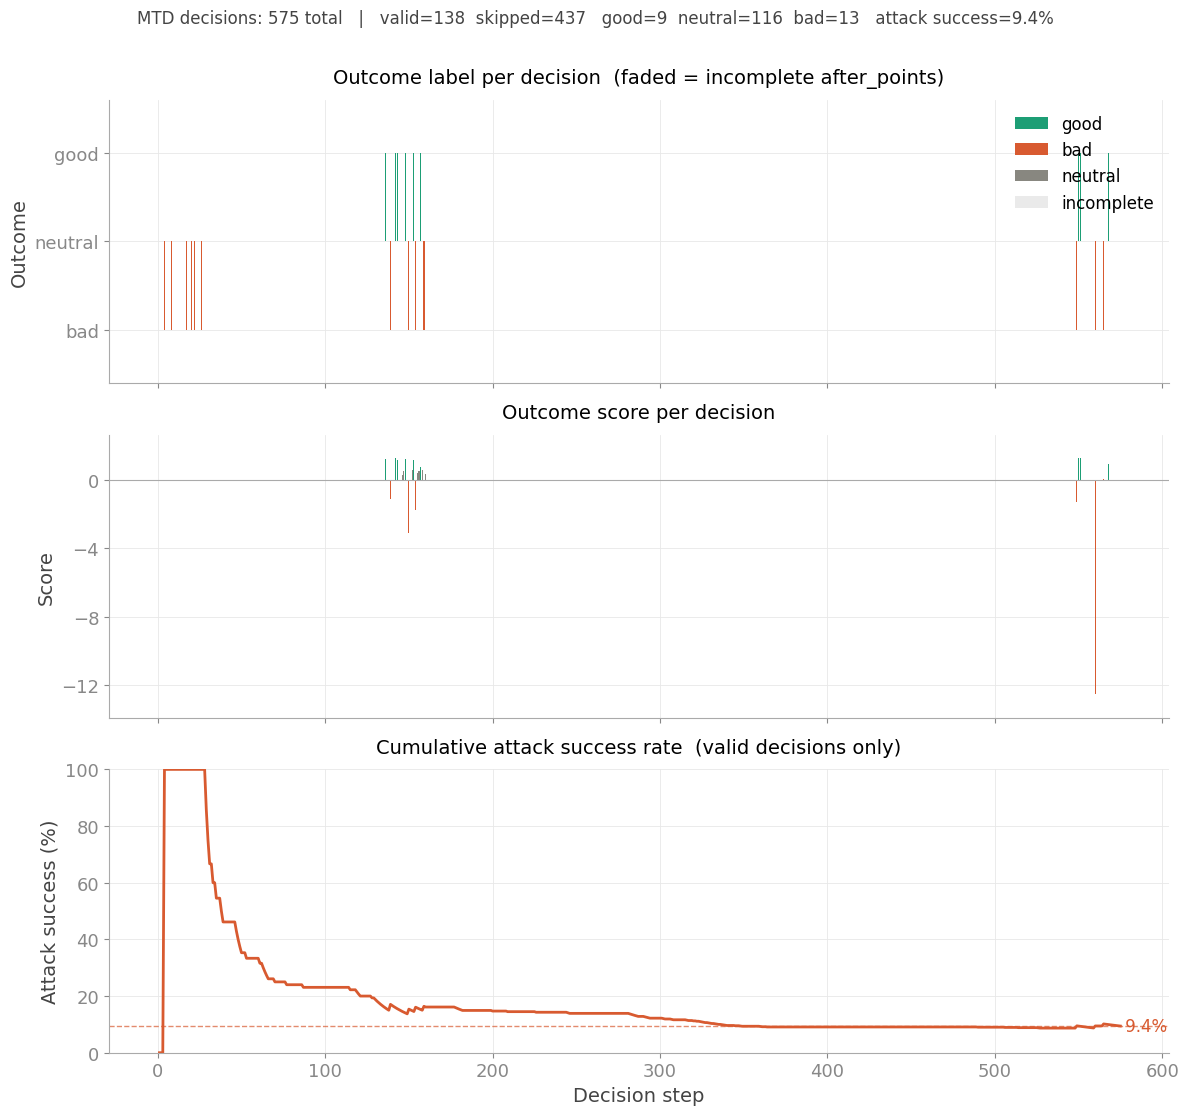

In [2]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── load ───────────────────────────────────────────────────────────────────

records = []
with open("examples.jsonl") as f:
    for i, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"  Skipping line {i}: {e}")

print(f"Loaded {len(records)} records")

# ── helper: check if all selected/other entries have 4 after_points ────────

def has_full_after_points(record, n=4):
    trace = record.get("validation_trace", {})
    for key in ("selected_hosts", "selected_links",
                "other_candidate_hosts", "other_candidate_links"):
        for entry in trace.get(key, []):
            pts = entry.get("after_points", {})
            # after_points is a dict of metric -> list
            for v in pts.values():
                if isinstance(v, list) and len(v) < n:
                    return False
    return True

# ── extract ────────────────────────────────────────────────────────────────

LABEL_COLOR = {"good": "#1D9E75", "bad": "#D85A30", "neutral": "#888780"}
LABEL_VAL   = {"good": 1, "neutral": 0, "bad": -1}

labels = []
scores = []
valid  = []   # track which steps passed the 4-point filter

for r in records:
    outcome = r.get("outcome", {})
    if has_full_after_points(r):
        labels.append(outcome.get("label", "neutral"))
        scores.append(outcome.get("score", 0.0))
        valid.append(True)
    else:
        labels.append("neutral")   # treat incomplete as neutral
        scores.append(0.0)
        valid.append(False)

steps      = list(range(1, len(records) + 1))
label_vals = [LABEL_VAL[l] for l in labels]

# running attack success rate — only count valid steps
cum_bad   = []
cum_total = []
running   = 0
valid_so_far = 0
for i, (l, v) in enumerate(zip(labels, valid)):
    if v:
        valid_so_far += 1
        if l == "bad":
            running += 1
    cum_bad.append(running)
    cum_total.append(max(valid_so_far, 1))

attack_rate = [b / t * 100 for b, t in zip(cum_bad, cum_total)]

# ── style ──────────────────────────────────────────────────────────────────

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.grid":          True,
    "grid.color":         "#e8e8e8",
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.edgecolor":     "#aaaaaa",
    "axes.linewidth":     0.8,
    "xtick.color":        "#888888",
    "ytick.color":        "#888888",
    "xtick.labelsize":    13,
    "ytick.labelsize":    13,
    "axes.labelsize":     14,
    "axes.labelcolor":    "#444444",
    "axes.titlesize":     14,
    "axes.titleweight":   "normal",
    "axes.titlepad":      12,
    "legend.fontsize":    12,
    "legend.frameon":     False,
    "font.family":        "sans-serif",
})

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
fig.subplots_adjust(hspace=0.45)

# ── plot 1: outcome label per decision ────────────────────────────────────

ax = axes[0]
for step, lv, lab, v in zip(steps, label_vals, labels, valid):
    color   = LABEL_COLOR[lab] if v else "#cccccc"
    alpha   = 1.0 if v else 0.4
    ax.bar(step, lv, color=color, width=0.7, zorder=2, alpha=alpha)

ax.set_ylim(-1.6, 1.6)
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["bad", "neutral", "good"])
ax.set_title("Outcome label per decision  (faded = incomplete after_points)")
ax.set_ylabel("Outcome")

for lab, col in LABEL_COLOR.items():
    ax.bar(0, 0, color=col, label=lab)
ax.bar(0, 0, color="#cccccc", alpha=0.4, label="incomplete")
ax.legend(loc="upper right")

# ── plot 2: outcome score per decision ────────────────────────────────────

ax = axes[1]
for step, sc, lab, v in zip(steps, scores, labels, valid):
    color = LABEL_COLOR[lab] if v else "#cccccc"
    alpha = 1.0 if v else 0.4
    ax.bar(step, sc, color=color, width=0.7, zorder=2, alpha=alpha)

ax.axhline(0, color="#aaaaaa", linewidth=0.8)
valid_scores = [s for s, v in zip(scores, valid) if v]
if valid_scores:
    mn, mx = min(valid_scores), max(valid_scores)
    pad = (mx - mn) * 0.1 or 0.5
    ax.set_ylim(mn - pad, mx + pad)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_title("Outcome score per decision")
ax.set_ylabel("Score")

# ── plot 3: cumulative attack success rate ────────────────────────────────

ax = axes[2]
ax.plot(steps, attack_rate, color="#D85A30", linewidth=2,
        label="Attack success rate")

final_rate = attack_rate[-1]
ax.axhline(final_rate, color="#D85A30", linewidth=1.0,
           linestyle="--", alpha=0.7)
ax.text(steps[-1], final_rate, f" {final_rate:.1f}%",
        color="#D85A30", va="center", fontsize=12)

ax.set_ylim(0, 100)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_title("Cumulative attack success rate  (valid decisions only)")
ax.set_xlabel("Decision step")
ax.set_ylabel("Attack success (%)")

# ── final stats ────────────────────────────────────────────────────────────

total      = len(records)
n_valid    = sum(valid)
n_bad      = sum(1 for l, v in zip(labels, valid) if l == "bad"  and v)
n_good     = sum(1 for l, v in zip(labels, valid) if l == "good" and v)
n_neut     = sum(1 for l, v in zip(labels, valid) if l == "neutral" and v)
n_skip     = total - n_valid

fig.suptitle(
    f"MTD decisions: {total} total   |   valid={n_valid}  skipped={n_skip}   "
    f"good={n_good}  neutral={n_neut}  bad={n_bad}   "
    f"attack success={final_rate:.1f}%",
    fontsize=12, y=1.01, color="#444444"
)

plt.tight_layout()
plt.savefig("mtd_outcomes.png", dpi=150, bbox_inches="tight")
plt.show()

  Skipping line 38: Expecting value: line 1 column 1 (char 0)
Loaded 575 records


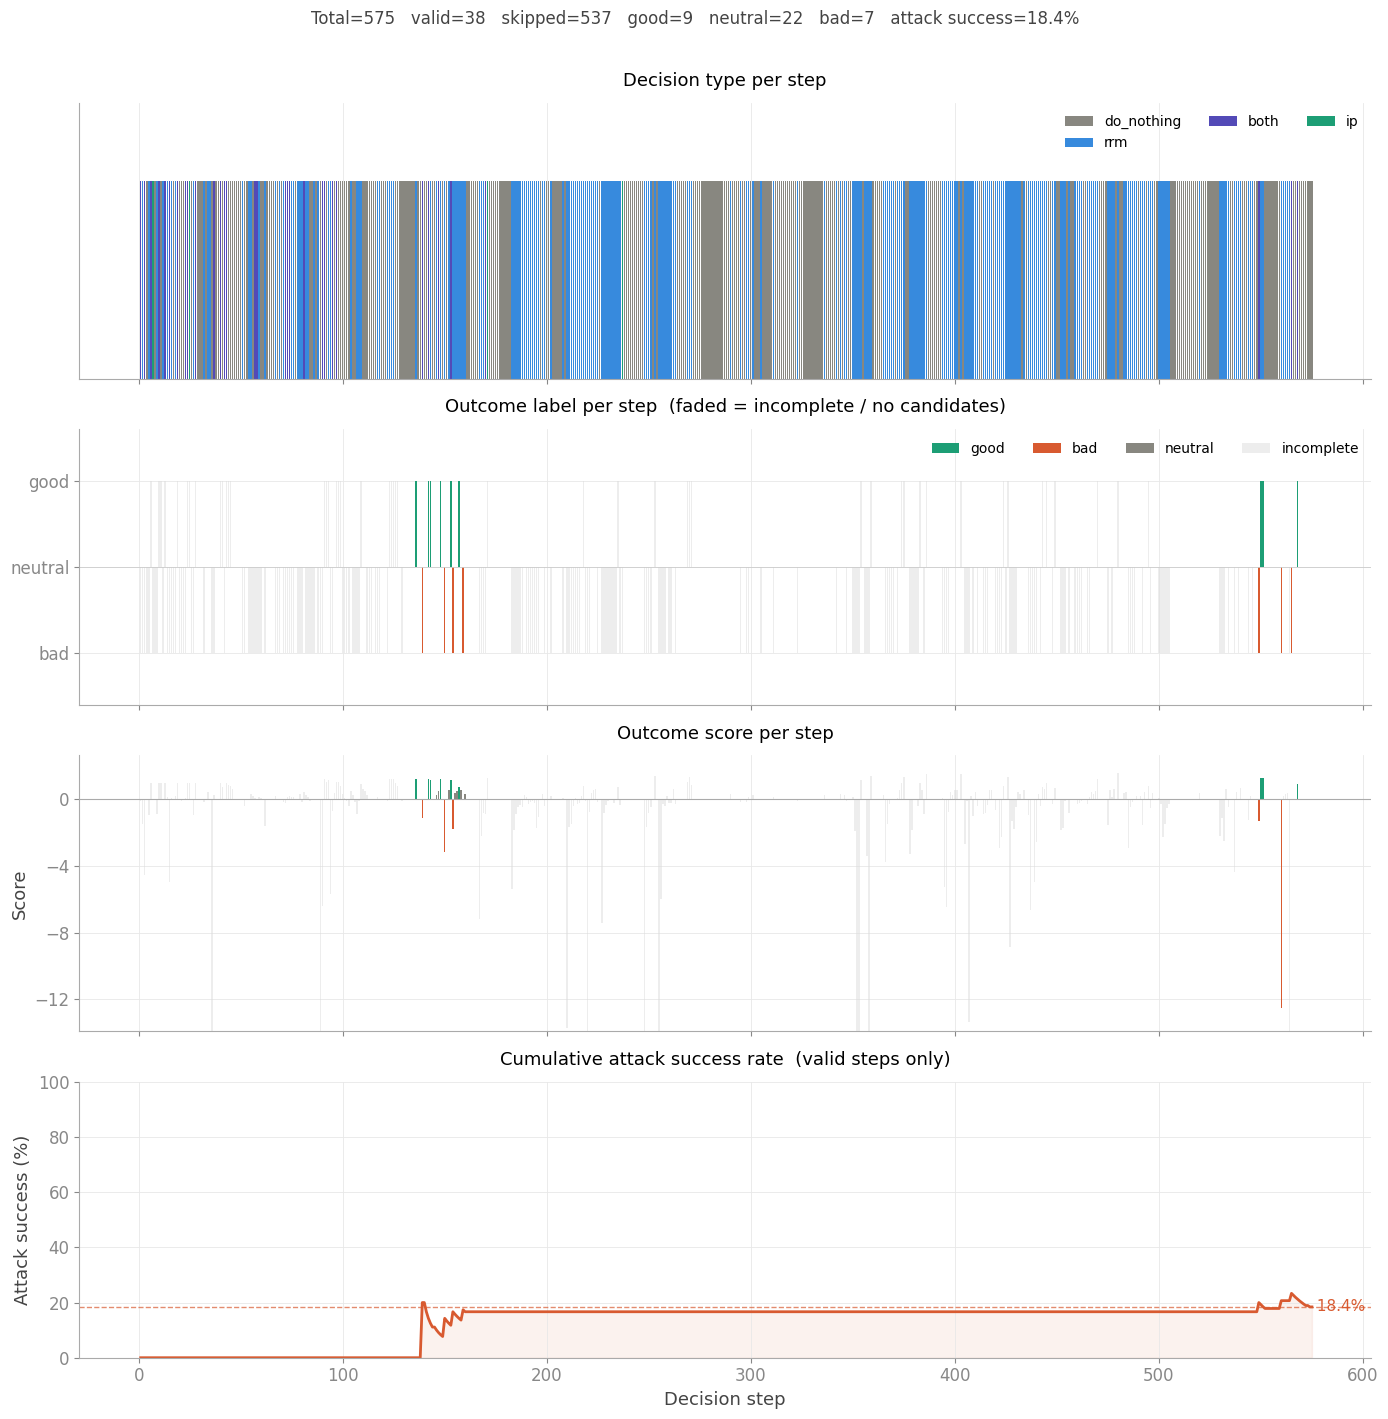

In [3]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── load ───────────────────────────────────────────────────────────────────

records = []
with open("examples.jsonl") as f:
    for i, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"  Skipping line {i}: {e}")

print(f"Loaded {len(records)} records")

# ── helpers ────────────────────────────────────────────────────────────────

def has_full_after_points(record, n=4):
    trace = record.get("validation_trace", {})
    for key in ("selected_hosts", "selected_links",
                "other_candidate_hosts", "other_candidate_links"):
        for entry in trace.get(key, []):
            for v in entry.get("after_points", {}).values():
                if isinstance(v, list) and len(v) < n:
                    return False
    return True

def get_decision(record):
    return record.get("decision", {}).get("final_decision", "unknown")

def has_any_candidates(record):
    trace = record.get("validation_trace", {})
    return any(
        trace.get(k) for k in ("selected_hosts", "selected_links",
                               "other_candidate_hosts", "other_candidate_links")
    )

# ── extract ────────────────────────────────────────────────────────────────

LABEL_COLOR = {"good": "#1D9E75", "bad": "#D85A30", "neutral": "#888780"}
LABEL_VAL   = {"good": 1, "neutral": 0, "bad": -1}

steps      = list(range(1, len(records) + 1))
labels     = []
scores     = []
valid      = []
decisions  = []

for r in records:
    outcome  = r.get("outcome", {})
    is_valid = has_full_after_points(r) and has_any_candidates(r)
    labels.append(outcome.get("label", "neutral"))
    scores.append(outcome.get("score", 0.0))
    valid.append(is_valid)
    decisions.append(get_decision(r))

label_vals = [LABEL_VAL[l] for l in labels]

# cumulative attack success rate (valid steps only)
cum_bad, cum_valid, running, valid_so_far = [], [], 0, 0
for l, v in zip(labels, valid):
    if v:
        valid_so_far += 1
        if l == "bad":
            running += 1
    cum_bad.append(running)
    cum_valid.append(max(valid_so_far, 1))

attack_rate = [b / t * 100 for b, t in zip(cum_bad, cum_valid)]

# decision type mapping for color
DECISION_COLOR = {
    "do_nothing": "#888780",
    "rrm":        "#378ADD",
    "both":       "#534AB7",
    "ip":         "#1D9E75",
    "route":      "#BA7517",
    "unknown":    "#cccccc",
}

# ── style ──────────────────────────────────────────────────────────────────

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.grid":          True,
    "grid.color":         "#e8e8e8",
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.edgecolor":     "#aaaaaa",
    "axes.linewidth":     0.8,
    "xtick.color":        "#888888",
    "ytick.color":        "#888888",
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "axes.labelsize":     13,
    "axes.labelcolor":    "#444444",
    "axes.titlesize":     13,
    "axes.titleweight":   "normal",
    "axes.titlepad":      12,
    "legend.fontsize":    10,
    "legend.frameon":     False,
    "font.family":        "sans-serif",
})

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fig.subplots_adjust(hspace=0.5)

# ── plot 1: decision type per step ────────────────────────────────────────

ax = axes[0]
for step, dec in zip(steps, decisions):
    color = DECISION_COLOR.get(dec, "#cccccc")
    ax.bar(step, 1, color=color, width=0.7, zorder=2)

ax.set_ylim(0, 1.4)
ax.set_yticks([])
ax.set_title("Decision type per step")

for dec, col in DECISION_COLOR.items():
    if dec in set(decisions):
        ax.bar(0, 0, color=col, label=dec)
ax.legend(loc="upper right", ncol=3)

# ── plot 2: outcome label per step ────────────────────────────────────────

ax = axes[1]
for step, lv, lab, v in zip(steps, label_vals, labels, valid):
    color = LABEL_COLOR[lab] if v else "#dddddd"
    alpha = 1.0 if v else 0.5
    ax.bar(step, lv, color=color, width=0.7, zorder=2, alpha=alpha)

ax.axhline(0, color="#cccccc", linewidth=0.6)
ax.set_ylim(-1.6, 1.6)
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["bad", "neutral", "good"])
ax.set_title("Outcome label per step  (faded = incomplete / no candidates)")

for lab, col in LABEL_COLOR.items():
    ax.bar(0, 0, color=col, label=lab)
ax.bar(0, 0, color="#dddddd", alpha=0.5, label="incomplete")
ax.legend(loc="upper right", ncol=4)

# ── plot 3: outcome score per step ────────────────────────────────────────

ax = axes[2]
for step, sc, lab, v in zip(steps, scores, labels, valid):
    color = LABEL_COLOR[lab] if v else "#dddddd"
    alpha = 1.0 if v else 0.5
    ax.bar(step, sc, color=color, width=0.7, zorder=2, alpha=alpha)

ax.axhline(0, color="#aaaaaa", linewidth=0.8)
valid_scores = [s for s, v in zip(scores, valid) if v]
if valid_scores:
    mn, mx = min(valid_scores), max(valid_scores)
    pad = (mx - mn) * 0.1 or 0.5
    ax.set_ylim(mn - pad, mx + pad)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_title("Outcome score per step")
ax.set_ylabel("Score")

# ── plot 4: cumulative attack success rate ────────────────────────────────

ax = axes[3]
ax.plot(steps, attack_rate, color="#D85A30", linewidth=2)
ax.fill_between(steps, attack_rate, alpha=0.08, color="#D85A30")

final_rate = attack_rate[-1]
ax.axhline(final_rate, color="#D85A30", linewidth=1.0,
           linestyle="--", alpha=0.7)
ax.text(steps[-1], final_rate, f" {final_rate:.1f}%",
        color="#D85A30", va="center", fontsize=11)

ax.set_ylim(0, max(100, final_rate + 5))
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_title("Cumulative attack success rate  (valid steps only)")
ax.set_xlabel("Decision step")
ax.set_ylabel("Attack success (%)")

# ── suptitle ───────────────────────────────────────────────────────────────

total   = len(records)
n_valid = sum(valid)
n_bad   = sum(1 for l, v in zip(labels, valid) if l == "bad"     and v)
n_good  = sum(1 for l, v in zip(labels, valid) if l == "good"    and v)
n_neut  = sum(1 for l, v in zip(labels, valid) if l == "neutral" and v)
n_skip  = total - n_valid

fig.suptitle(
    f"Total={total}   valid={n_valid}   skipped={n_skip}   "
    f"good={n_good}   neutral={n_neut}   bad={n_bad}   "
    f"attack success={final_rate:.1f}%",
    fontsize=12, y=1.01, color="#444444"
)

plt.tight_layout()
plt.savefig("mtd_outcomes.png", dpi=150, bbox_inches="tight")
plt.show()

  Skipping line 38: Expecting value: line 1 column 1 (char 0)
Loaded 575 records


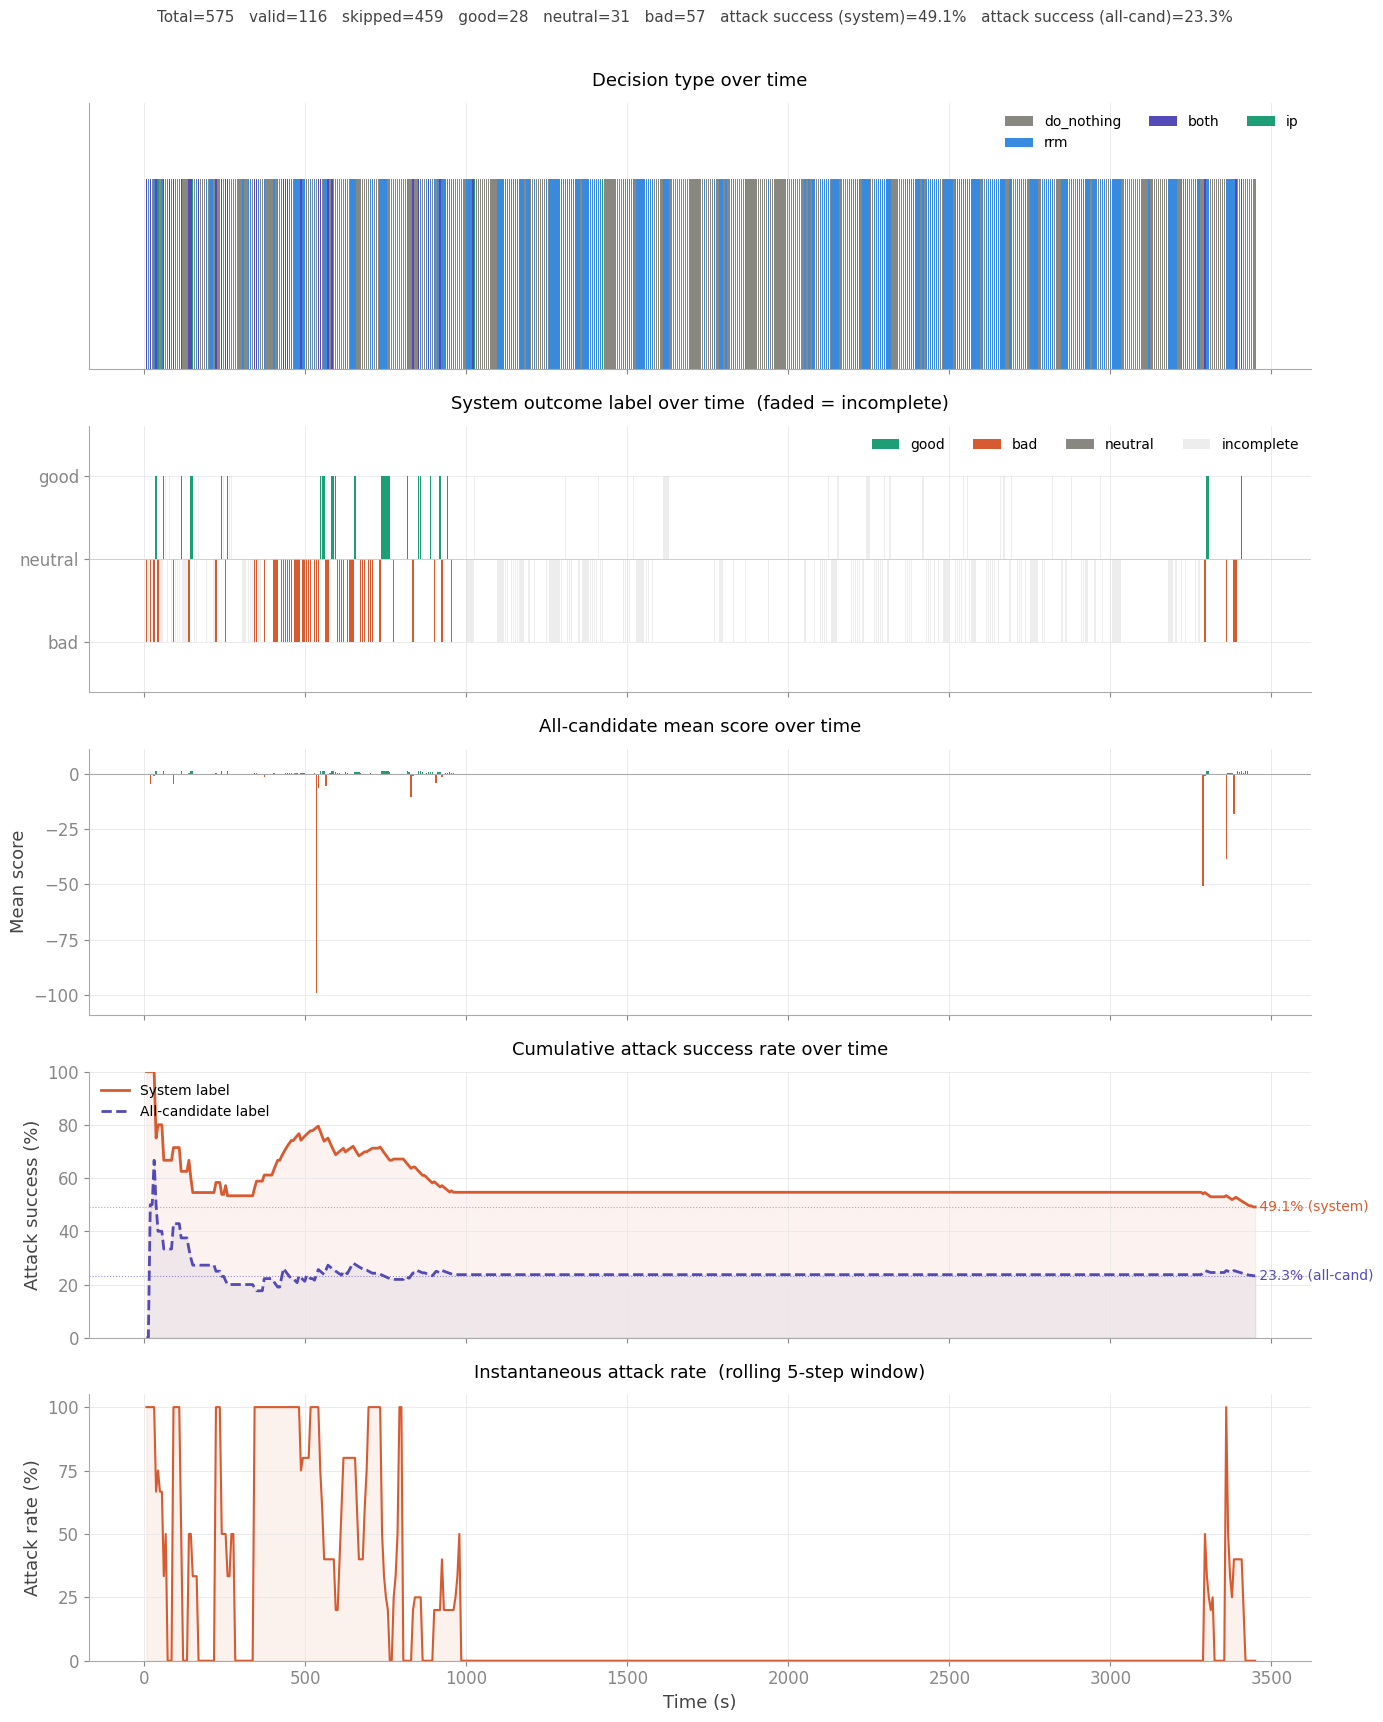

In [4]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── config ─────────────────────────────────────────────────────────────────

MIN_AFTER_POINTS  = 2
POLLING_INTERVAL  = 6   # seconds per step — adjust to match your setup

# ── load ───────────────────────────────────────────────────────────────────

records = []
with open("examples.jsonl") as f:
    for i, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"  Skipping line {i}: {e}")

print(f"Loaded {len(records)} records")

# ── helpers ────────────────────────────────────────────────────────────────

MIN_AFTER_POINTS = 2

def has_full_after_points(record, n=MIN_AFTER_POINTS):
    trace = record.get("validation_trace", {})
    for key in ("selected_hosts", "selected_links",
                "other_candidate_hosts", "other_candidate_links"):
        for entry in trace.get(key, []):
            for v in entry.get("after_points", {}).values():
                if isinstance(v, list) and len(v) < n:
                    return False
    return True

def has_any_candidates(record):
    trace = record.get("validation_trace", {})
    return any(
        trace.get(k) for k in ("selected_hosts", "selected_links",
                               "other_candidate_hosts", "other_candidate_links")
    )

def get_decision(record):
    return record.get("decision", {}).get("final_decision", "unknown")

def all_candidate_scores(record):
    """Collect scores from ALL candidates — selected and other."""
    trace  = record.get("validation_trace", {})
    scores = []
    for key in ("selected_hosts", "selected_links",
                "other_candidate_hosts", "other_candidate_links"):
        for entry in trace.get(key, []):
            if "score" in entry:
                # only include if enough after_points
                pts = entry.get("after_points", {})
                min_len = min(
                    (len(v) for v in pts.values() if isinstance(v, list)),
                    default=MIN_AFTER_POINTS
                )
                if min_len >= MIN_AFTER_POINTS:
                    scores.append(entry["score"])
    return scores

def derive_label(mean_score):
    if mean_score >  0.1:  return "good"
    if mean_score < -0.1:  return "bad"
    return "neutral"

# ── extract ────────────────────────────────────────────────────────────────

LABEL_COLOR = {"good": "#1D9E75", "bad": "#D85A30", "neutral": "#888780"}
LABEL_VAL   = {"good": 1, "neutral": 0, "bad": -1}

DECISION_COLOR = {
    "do_nothing": "#888780",
    "rrm":        "#378ADD",
    "both":       "#534AB7",
    "ip":         "#1D9E75",
    "route":      "#BA7517",
    "unknown":    "#cccccc",
}

steps     = list(range(1, len(records) + 1))
times_sec = [s * POLLING_INTERVAL for s in steps]   # wall-clock seconds

labels     = []
scores     = []
all_scores = []   # mean across ALL candidates
valid      = []
decisions  = []

for r in records:
    outcome  = r.get("outcome", {})
    is_valid = has_full_after_points(r) and has_any_candidates(r)

    # system label/score
    labels.append(outcome.get("label", "neutral"))
    scores.append(outcome.get("score", 0.0))
    valid.append(is_valid)
    decisions.append(get_decision(r))

    # all-candidate mean score
    cand_scores = all_candidate_scores(r)
    if cand_scores and is_valid:
        all_scores.append(sum(cand_scores) / len(cand_scores))
    else:
        all_scores.append(None)

label_vals = [LABEL_VAL[l] for l in labels]

# derived label from all candidates
all_labels = [
    derive_label(s) if s is not None else "neutral"
    for s in all_scores
]

# cumulative attack success rate over time (valid steps only)
# using system label
cum_bad_sys, cum_valid_sys, run_sys, vsf_sys = [], [], 0, 0
# using all-candidate derived label
cum_bad_all, cum_valid_all, run_all, vsf_all = [], [], 0, 0

for l_sys, l_all, v in zip(labels, all_labels, valid):
    if v:
        vsf_sys += 1
        vsf_all += 1
        if l_sys  == "bad": run_sys += 1
        if l_all  == "bad": run_all += 1
    cum_bad_sys.append(run_sys);  cum_valid_sys.append(max(vsf_sys, 1))
    cum_bad_all.append(run_all);  cum_valid_all.append(max(vsf_all, 1))

attack_rate_sys = [b / t * 100 for b, t in zip(cum_bad_sys, cum_valid_sys)]
attack_rate_all = [b / t * 100 for b, t in zip(cum_bad_all, cum_valid_all)]

# ── style ──────────────────────────────────────────────────────────────────

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.grid":          True,
    "grid.color":         "#e8e8e8",
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.edgecolor":     "#aaaaaa",
    "axes.linewidth":     0.8,
    "xtick.color":        "#888888",
    "ytick.color":        "#888888",
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "axes.labelsize":     13,
    "axes.labelcolor":    "#444444",
    "axes.titlesize":     13,
    "axes.titleweight":   "normal",
    "axes.titlepad":      12,
    "legend.fontsize":    10,
    "legend.frameon":     False,
    "font.family":        "sans-serif",
})

fig, axes = plt.subplots(5, 1, figsize=(14, 17), sharex=True)
fig.subplots_adjust(hspace=0.5)

# ── plot 1: decision type ─────────────────────────────────────────────────

ax = axes[0]
for t, dec in zip(times_sec, decisions):
    ax.bar(t, 1, color=DECISION_COLOR.get(dec, "#cccccc"),
           width=POLLING_INTERVAL * 0.7, zorder=2)
ax.set_ylim(0, 1.4)
ax.set_yticks([])
ax.set_title("Decision type over time")
for dec, col in DECISION_COLOR.items():
    if dec in set(decisions):
        ax.bar(0, 0, color=col, label=dec)
ax.legend(loc="upper right", ncol=3)

# ── plot 2: system outcome label ──────────────────────────────────────────

ax = axes[1]
for t, lv, lab, v in zip(times_sec, label_vals, labels, valid):
    color = LABEL_COLOR[lab] if v else "#dddddd"
    ax.bar(t, lv, color=color, alpha=1.0 if v else 0.5,
           width=POLLING_INTERVAL * 0.7, zorder=2)
ax.axhline(0, color="#cccccc", linewidth=0.6)
ax.set_ylim(-1.6, 1.6)
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["bad", "neutral", "good"])
ax.set_title("System outcome label over time  (faded = incomplete)")
for lab, col in LABEL_COLOR.items():
    ax.bar(0, 0, color=col, label=lab)
ax.bar(0, 0, color="#dddddd", alpha=0.5, label="incomplete")
ax.legend(loc="upper right", ncol=4)

# ── plot 3: all-candidate mean score ─────────────────────────────────────

ax = axes[2]
for t, sc, lab, v in zip(times_sec, all_scores, all_labels, valid):
    if sc is None:
        ax.bar(t, 0, color="#dddddd", alpha=0.4,
               width=POLLING_INTERVAL * 0.7, zorder=2)
    else:
        ax.bar(t, sc, color=LABEL_COLOR[lab],
               width=POLLING_INTERVAL * 0.7, zorder=2)
ax.axhline(0, color="#aaaaaa", linewidth=0.8)
valid_all_sc = [s for s in all_scores if s is not None]
if valid_all_sc:
    mn, mx = min(valid_all_sc), max(valid_all_sc)
    pad = (mx - mn) * 0.1 or 0.5
    ax.set_ylim(mn - pad, mx + pad)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_title("All-candidate mean score over time")
ax.set_ylabel("Mean score")

# ── plot 4: cumulative attack success rate over time ─────────────────────

ax = axes[3]
ax.plot(times_sec, attack_rate_sys, color="#D85A30", linewidth=2,
        label="System label")
ax.plot(times_sec, attack_rate_all, color="#534AB7", linewidth=2,
        linestyle="--", label="All-candidate label")
ax.fill_between(times_sec, attack_rate_sys, alpha=0.07, color="#D85A30")
ax.fill_between(times_sec, attack_rate_all, alpha=0.07, color="#534AB7")

for rate, col, label in [
    (attack_rate_sys[-1], "#D85A30", "system"),
    (attack_rate_all[-1], "#534AB7", "all-cand"),
]:
    ax.axhline(rate, color=col, linewidth=0.8, linestyle=":", alpha=0.6)
    ax.text(times_sec[-1], rate, f" {rate:.1f}% ({label})",
            color=col, va="center", fontsize=10)

ax.set_ylim(0, 100)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_title("Cumulative attack success rate over time")
ax.set_ylabel("Attack success (%)")
ax.legend(loc="upper left")

# ── plot 5: instantaneous bad rate (rolling window) ───────────────────────

WINDOW = 5   # steps
ax = axes[4]
rolling = []
for i in range(len(labels)):
    window_labels = [
        labels[j] for j in range(max(0, i - WINDOW + 1), i + 1)
        if valid[j]
    ]
    if window_labels:
        rolling.append(window_labels.count("bad") / len(window_labels) * 100)
    else:
        rolling.append(0.0)

ax.plot(times_sec, rolling, color="#D85A30", linewidth=1.5)
ax.fill_between(times_sec, rolling, alpha=0.08, color="#D85A30")
ax.set_ylim(0, 105)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_title(f"Instantaneous attack rate  (rolling {WINDOW}-step window)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Attack rate (%)")

# ── suptitle ───────────────────────────────────────────────────────────────

total   = len(records)
n_valid = sum(valid)
n_bad   = sum(1 for l, v in zip(labels, valid) if l == "bad"     and v)
n_good  = sum(1 for l, v in zip(labels, valid) if l == "good"    and v)
n_neut  = sum(1 for l, v in zip(labels, valid) if l == "neutral" and v)

fig.suptitle(
    f"Total={total}   valid={n_valid}   skipped={total - n_valid}   "
    f"good={n_good}   neutral={n_neut}   bad={n_bad}   "
    f"attack success (system)={attack_rate_sys[-1]:.1f}%   "
    f"attack success (all-cand)={attack_rate_all[-1]:.1f}%",
    fontsize=11, y=1.01, color="#444444"
)

plt.tight_layout()
plt.savefig("mtd_outcomes.png", dpi=150, bbox_inches="tight")
plt.show()

  Skipping line 38: Expecting value: line 1 column 1 (char 0)
Loaded 595 records


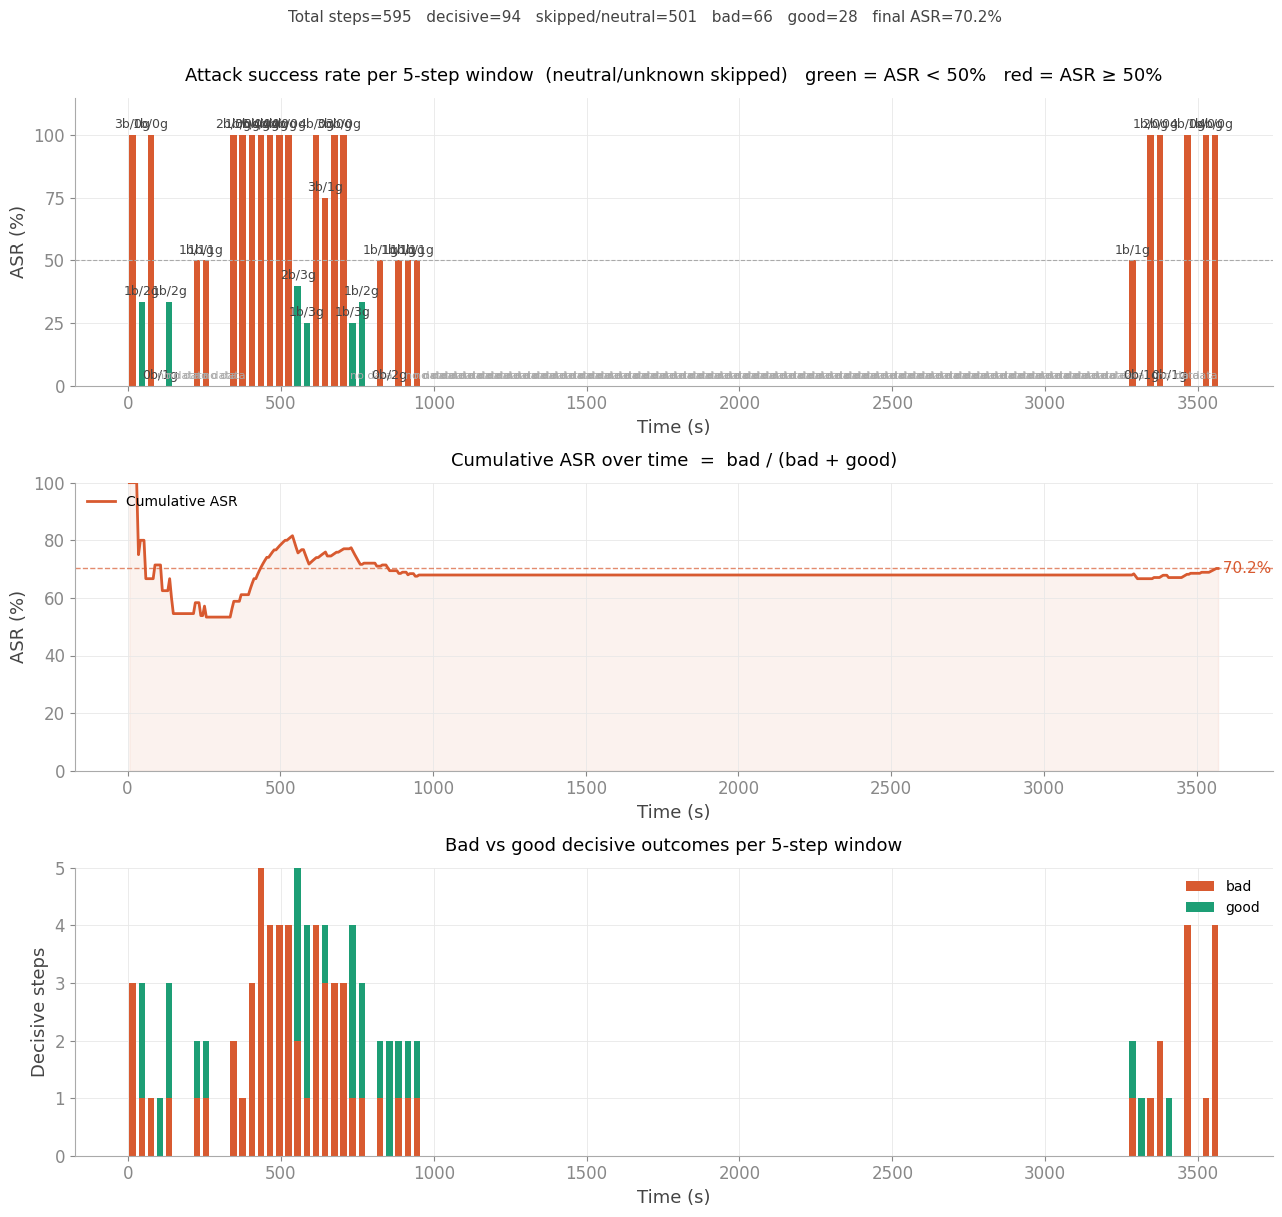

In [2]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── config ─────────────────────────────────────────────────────────────────

MIN_AFTER_POINTS = 2
POLLING_INTERVAL = 6    # seconds per step
WINDOW_SIZE      = 5    # steps per window

# ── load ───────────────────────────────────────────────────────────────────

records = []
with open("examples.jsonl") as f:
    for i, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"  Skipping line {i}: {e}")

print(f"Loaded {len(records)} records")

# ── helpers ────────────────────────────────────────────────────────────────

def has_full_after_points(record, n=MIN_AFTER_POINTS):
    trace = record.get("validation_trace", {})
    for key in ("selected_hosts", "selected_links",
                "other_candidate_hosts", "other_candidate_links"):
        for entry in trace.get(key, []):
            for v in entry.get("after_points", {}).values():
                if isinstance(v, list) and len(v) < n:
                    return False
    return True

def has_any_candidates(record):
    trace = record.get("validation_trace", {})
    return any(
        trace.get(k) for k in ("selected_hosts", "selected_links",
                               "other_candidate_hosts", "other_candidate_links")
    )

def get_decision(record):
    return record.get("decision", {}).get("final_decision", "unknown")

# ── extract ────────────────────────────────────────────────────────────────

LABEL_COLOR = {"good": "#1D9E75", "bad": "#D85A30"}
DECISION_COLOR = {
    "do_nothing": "#888780",
    "rrm":        "#378ADD",
    "both":       "#534AB7",
    "ip":         "#1D9E75",
    "route":      "#BA7517",
}

labels    = []
valid     = []
decisions = []

for r in records:
    outcome  = r.get("outcome", {})
    is_valid = has_full_after_points(r) and has_any_candidates(r)
    lab      = outcome.get("label", "neutral")
    dec      = get_decision(r)
    labels.append(lab)
    valid.append(is_valid)
    decisions.append(dec)

# ── window ASR: parse every WINDOW_SIZE steps ─────────────────────────────
# only count decisive (bad or good) valid steps
# skip neutral, unknown, incomplete

window_times = []   # centre time of each window in seconds
window_asr   = []   # ASR for that window
window_bad   = []
window_good  = []
window_total = []

n = len(records)
for start in range(0, n, WINDOW_SIZE):
    end   = min(start + WINDOW_SIZE, n)
    chunk = [
        labels[i]
        for i in range(start, end)
        if valid[i] and labels[i] in ("bad", "good")
    ]

    n_bad  = chunk.count("bad")
    n_good = chunk.count("good")
    n_dec  = n_bad + n_good

    centre_step = (start + end) / 2
    window_times.append(centre_step * POLLING_INTERVAL)
    window_bad.append(n_bad)
    window_good.append(n_good)
    window_total.append(n_dec)
    window_asr.append(n_bad / n_dec * 100 if n_dec > 0 else None)

# cumulative ASR over time (decisive only)
cum_bad_run, cum_dec_run = 0, 0
cum_times, cum_asr = [], []
for i, (lab, v) in enumerate(zip(labels, valid)):
    if v and lab in ("bad", "good"):
        cum_dec_run += 1
        if lab == "bad":
            cum_bad_run += 1
    if cum_dec_run > 0:
        cum_times.append((i + 1) * POLLING_INTERVAL)
        cum_asr.append(cum_bad_run / cum_dec_run * 100)

# ── style ──────────────────────────────────────────────────────────────────

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.grid":          True,
    "grid.color":         "#e8e8e8",
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.edgecolor":     "#aaaaaa",
    "axes.linewidth":     0.8,
    "xtick.color":        "#888888",
    "ytick.color":        "#888888",
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "axes.labelsize":     13,
    "axes.labelcolor":    "#444444",
    "axes.titlesize":     13,
    "axes.titleweight":   "normal",
    "axes.titlepad":      12,
    "legend.fontsize":    10,
    "legend.frameon":     False,
    "font.family":        "sans-serif",
})

fig, axes = plt.subplots(3, 1, figsize=(13, 12))
fig.subplots_adjust(hspace=0.5)

# ── plot 1: per-window ASR bar chart ─────────────────────────────────────

ax = axes[0]
bar_colors = []
for asr in window_asr:
    if asr is None:
        bar_colors.append("#dddddd")
    elif asr >= 50:
        bar_colors.append("#D85A30")
    else:
        bar_colors.append("#1D9E75")

bars = ax.bar(
    window_times,
    [a if a is not None else 0 for a in window_asr],
    width=WINDOW_SIZE * POLLING_INTERVAL * 0.7,
    color=bar_colors,
    zorder=2
)

# annotate each bar with bad/good counts
for t, asr, nb, ng, nd in zip(
        window_times, window_asr, window_bad, window_good, window_total):
    if nd > 0:
        ax.text(t, (asr or 0) + 1.5, f"{nb}b/{ng}g",
                ha="center", va="bottom", fontsize=9, color="#444444")
    else:
        ax.text(t, 2, "no data", ha="center", va="bottom",
                fontsize=8, color="#aaaaaa")

ax.set_ylim(0, 115)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_xlabel("Time (s)")
ax.set_ylabel("ASR (%)")
ax.set_title(f"Attack success rate per {WINDOW_SIZE}-step window  "
             f"(neutral/unknown skipped)   "
             f"green = ASR < 50%   red = ASR ≥ 50%")
ax.axhline(50, color="#aaaaaa", linewidth=0.8, linestyle="--")

# ── plot 2: cumulative ASR over time ─────────────────────────────────────

ax = axes[1]
ax.plot(cum_times, cum_asr, color="#D85A30", linewidth=2,
        label="Cumulative ASR")
ax.fill_between(cum_times, cum_asr, alpha=0.08, color="#D85A30")

if cum_asr:
    final = cum_asr[-1]
    ax.axhline(final, color="#D85A30", linewidth=1.0,
               linestyle="--", alpha=0.7)
    ax.text(cum_times[-1], final, f" {final:.1f}%",
            color="#D85A30", va="center", fontsize=11)

ax.set_ylim(0, 100)
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.set_xlabel("Time (s)")
ax.set_ylabel("ASR (%)")
ax.set_title("Cumulative ASR over time  =  bad / (bad + good)")
ax.legend(loc="upper left")

# ── plot 3: stacked bar — bad vs good per window ──────────────────────────

ax = axes[2]
w = WINDOW_SIZE * POLLING_INTERVAL * 0.7
ax.bar(window_times, window_bad,  width=w, color="#D85A30",
       label="bad",  zorder=2)
ax.bar(window_times, window_good, width=w, color="#1D9E75",
       label="good", bottom=window_bad, zorder=2)

ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))
ax.set_xlabel("Time (s)")
ax.set_ylabel("Decisive steps")
ax.set_title(f"Bad vs good decisive outcomes per {WINDOW_SIZE}-step window")
ax.legend(loc="upper right")

# ── suptitle ───────────────────────────────────────────────────────────────

total_bad  = sum(window_bad)
total_good = sum(window_good)
total_dec  = total_bad + total_good
total_skip = sum(1 for l, v in zip(labels, valid)
                 if not v or l not in ("bad", "good"))
final_asr  = cum_asr[-1] if cum_asr else 0.0

fig.suptitle(
    f"Total steps={len(records)}   decisive={total_dec}   "
    f"skipped/neutral={total_skip}   "
    f"bad={total_bad}   good={total_good}   "
    f"final ASR={final_asr:.1f}%",
    fontsize=11, y=1.01, color="#444444"
)

plt.tight_layout()
plt.savefig("mtd_outcomes.png", dpi=150, bbox_inches="tight")
plt.show()

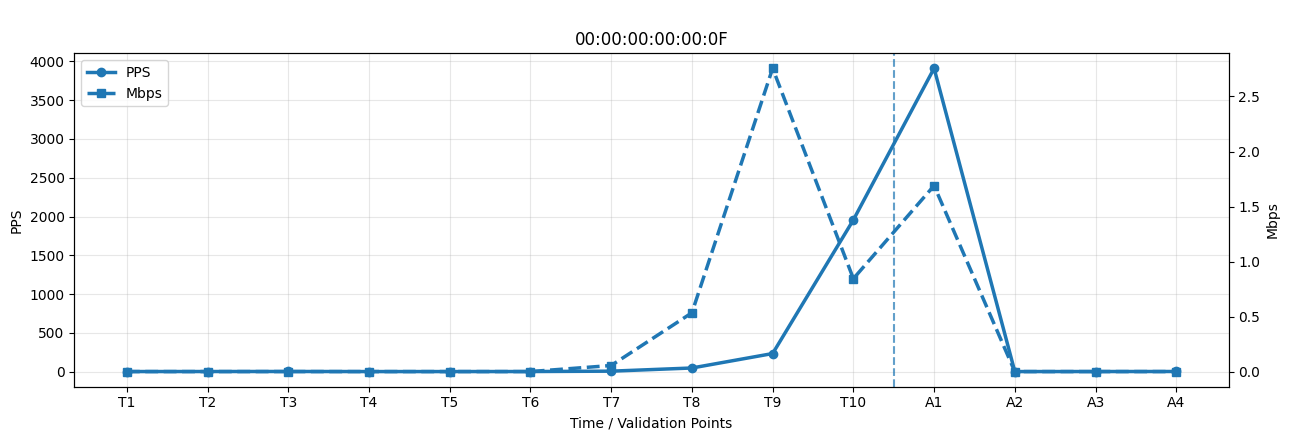

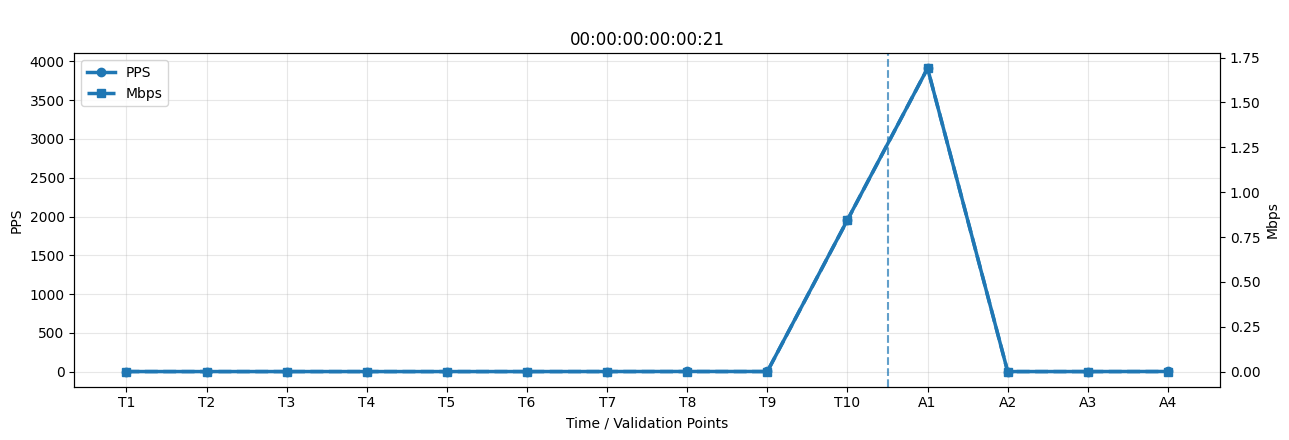

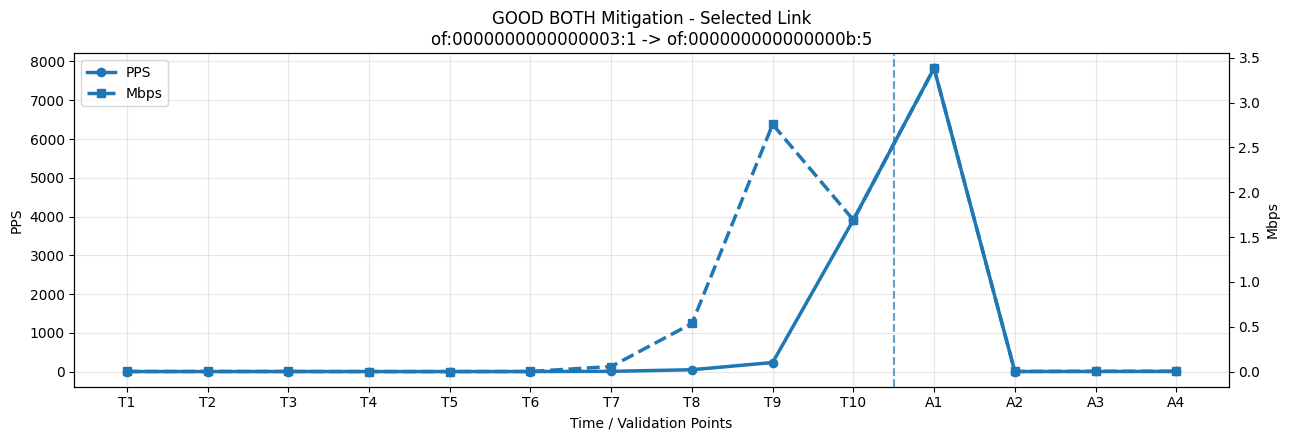

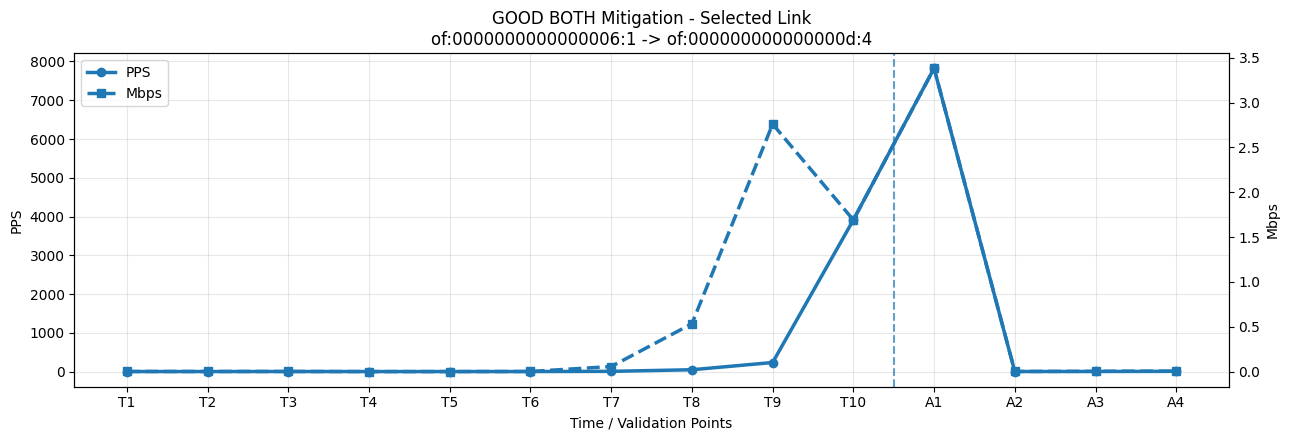

In [5]:
import matplotlib.pyplot as plt

record = {
    "candidates": {
        "host_stats": [
            {
                "mac": "00:00:00:00:00:0F",
                "tx_pps_trend": [0.85, 1.1, 1.7, 0.6, 0.6, 1.0, 5.69, 46.58, 232.94, 1955.96],
                "tx_kbps_trend": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 56.0, 535.0, 2756.0, 845.0],
            },
            {
                "mac": "00:00:00:00:00:21",
                "tx_pps_trend": [0.85, 0.6, 0.7, 0.6, 0.6, 0.7, 1.05, 1.65, 1.55, 1955.96],
                "tx_kbps_trend": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 845.0],
            },
        ],
        "link_stats": [
            {
                "link_id": "of:0000000000000003:1 -> of:000000000000000b:5",
                "rx_pps_trend": [1.55, 1.7, 2.4, 1.2, 1.2, 1.7, 6.74, 48.23, 234.49, 3911.93],
                "rx_kbps_trend": [2.0, 2.0, 2.0, 1.0, 1.0, 2.0, 57.0, 537.0, 2757.0, 1691.0],
            },
            {
                "link_id": "of:0000000000000006:1 -> of:000000000000000d:4",
                "rx_pps_trend": [1.55, 1.7, 2.4, 1.2, 1.2, 1.7, 6.74, 48.03, 234.69, 3911.93],
                "rx_kbps_trend": [2.0, 2.0, 2.0, 1.0, 1.0, 2.0, 57.0, 534.0, 2760.0, 1691.0],
            },
        ],
    },
    "validation_trace": {
        "selected_hosts": [
            {
                "mac": "00:00:00:00:00:0F",
                "after_points": {"pps": [3911.22, 0.6, 1.0, 1.5], "mbps": [1.69, 0.001, 0.001, 0.001]},
            },
            {
                "mac": "00:00:00:00:00:21",
                "after_points": {"pps": [3911.22, 0.6, 0.8, 1.6], "mbps": [1.69, 0.001, 0.001, 0.001]},
            },
        ],
        "selected_links": [
            {
                "link_id": "of:0000000000000003:1 -> of:000000000000000b:5",
                "after_points": {"pps": [7823.86, 2.4, 3.4, 4.2], "mbps": [3.382, 0.002, 0.004, 0.004]},
            },
            {
                "link_id": "of:0000000000000006:1 -> of:000000000000000d:4",
                "after_points": {"pps": [7823.86, 2.4, 3.0, 6.98], "mbps": [3.382, 0.002, 0.004, 0.006]},
            },
        ],
    },
}

def get_after(trace_list, key_name, key_value):
    for item in trace_list:
        if item.get(key_name) == key_value:
            return item["after_points"]
    return {"pps": [], "mbps": []}

def plot_10_before_4_after(name, before_pps, before_kbps, after_pps, after_mbps, title):
    pps = before_pps + after_pps
    mbps = [v / 1000 for v in before_kbps] + after_mbps

    x = list(range(1, len(pps) + 1))
    labels = [f"T{i}" for i in range(1, 11)] + [f"A{i}" for i in range(1, 5)]

    fig, ax1 = plt.subplots(figsize=(13, 4.5))

    ax1.plot(x, pps, marker="o", linewidth=2.5, label="PPS")
    ax1.axvline(10.5, linestyle="--", linewidth=1.5, alpha=0.7)
    # ax1.text(5.5, max(pps)*0.92, "10 candidate points", ha="center")
    # ax1.text(12.5, max(pps)*0.92, "4 after points", ha="center")

    ax1.set_xlabel("Time / Validation Points")
    ax1.set_ylabel("PPS")
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(x, mbps, marker="s", linestyle="--", linewidth=2.5, label="Mbps")
    ax2.set_ylabel("Mbps")

    ax1.set_title(f"{title}\n{name}")

    l1, lab1 = ax1.get_legend_handles_labels()
    l2, lab2 = ax2.get_legend_handles_labels()
    ax1.legend(l1 + l2, lab1 + lab2, loc="upper left")

    plt.tight_layout()
    plt.show()

# -----------------------------
# Host plots: 10 candidate + 4 after
# -----------------------------
for h in record["candidates"]["host_stats"]:
    after = get_after(
        record["validation_trace"]["selected_hosts"],
        "mac",
        h["mac"]
    )

    plot_10_before_4_after(
        name=h["mac"],
        before_pps=h["tx_pps_trend"],
        before_kbps=h["tx_kbps_trend"],
        after_pps=after["pps"],
        after_mbps=after["mbps"],
        title=""
    )

# -----------------------------
# Link plots: 10 candidate + 4 after
# -----------------------------
for l in record["candidates"]["link_stats"]:
    after = get_after(
        record["validation_trace"]["selected_links"],
        "link_id",
        l["link_id"]
    )

    plot_10_before_4_after(
        name=l["link_id"],
        before_pps=l["rx_pps_trend"],
        before_kbps=l["rx_kbps_trend"],
        after_pps=after["pps"],
        after_mbps=after["mbps"],
        title="GOOD BOTH Mitigation - Selected Link"
    )

[WARN] Expected 215 rows, but found 201 rows.
Loaded rows: 676 to 890
Total scenes: 201

Classification Report:
                          precision    recall  f1-score   support

               No_Attack       1.00      1.00      1.00       100
             Low_Anomaly       0.00      0.00      0.00         0
Attack_Effective_Defense       1.00      1.00      1.00        28
     Attack_Weak_Defense       1.00      1.00      1.00        21
   Attack_Failed_Defense       1.00      0.75      0.86        52

                accuracy                           0.94       201
               macro avg       0.80      0.75      0.77       201
            weighted avg       1.00      0.94      0.96       201



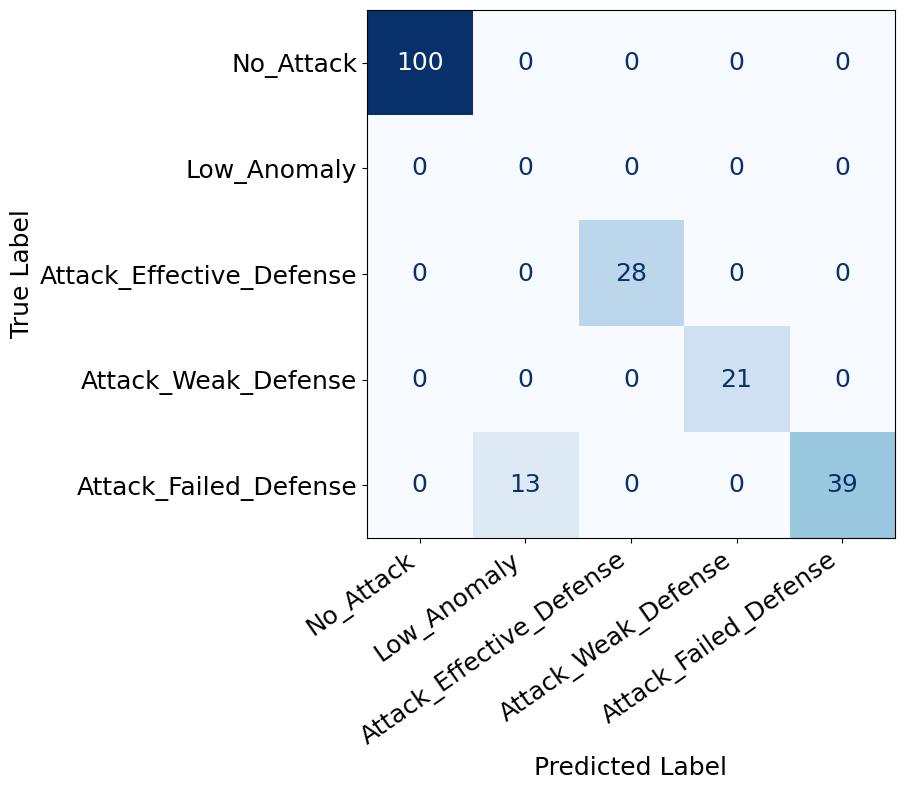

In [ ]:
# import json
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# # ==============================
# # CONFIG
# # ==============================
# JSONL_FILE = "examples.jsonl"

# START_ROW = 676
# END_ROW = 890

# ROW_NUMBERS = list(range(START_ROW, END_ROW + 1))

# LABELS = [
#     "No_Attack",
#     "Low_Anomaly",
#     "Attack_Effective_Defense",
#     "Attack_Weak_Defense",
#     "Attack_Failed_Defense"
# ]

# # ==============================
# # READ JSONL ROW RANGE
# # ==============================
# def read_jsonl_row_range(jsonl_file, start_row, end_row):
#     rows = []

#     with open(jsonl_file, "r", encoding="utf-8") as f:
#         for line_no, line in enumerate(f, start=1):
#             if start_row <= line_no <= end_row:
#                 line = line.strip()
#                 if line:
#                     rows.append(json.loads(line))

#             if line_no > end_row:
#                 break

#     expected = end_row - start_row + 1
#     if len(rows) != expected:
#         print(f"[WARN] Expected {expected} rows, but found {len(rows)} rows.")

#     return rows


# # ==============================
# # TRUE LABEL FROM JSONL OUTCOME
# # ==============================
# def map_row_to_true_label(row):
#     """
#     Uses outcome.label as the ground-truth outcome quality.
#     """
#     decision = row.get("decision", {}).get("final_decision", "do_nothing")
#     outcome_label = row.get("outcome", {}).get("label", "neutral")

#     if decision == "do_nothing":
#         return "No_Attack"

#     if outcome_label == "good":
#         return "Attack_Effective_Defense"

#     if outcome_label == "neutral":
#         return "Attack_Weak_Defense"

#     if outcome_label == "bad":
#         return "Attack_Failed_Defense"

#     return "Low_Anomaly"


# # ==============================
# # PREDICTED LABEL FROM DECISION
# # ==============================
# def map_row_to_pred_label(row):
#     """
#     Maps system decision + outcome into evaluation class.
#     """
#     decision = row.get("decision", {}).get("final_decision", "do_nothing")
#     outcome_label = row.get("outcome", {}).get("label", "neutral")

#     selected_hosts = row.get("validation_trace", {}).get("selected_hosts", [])
#     selected_links = row.get("validation_trace", {}).get("selected_links", [])

#     has_selected_targets = bool(selected_hosts or selected_links)
#     has_action = decision in ["ip", "rrm", "both"]

#     if decision == "do_nothing":
#         return "No_Attack"

#     if has_action and has_selected_targets and outcome_label == "good":
#         return "Attack_Effective_Defense"

#     if has_action and has_selected_targets and outcome_label == "neutral":
#         return "Attack_Weak_Defense"

#     if has_action and has_selected_targets and outcome_label == "bad":
#         return "Attack_Failed_Defense"

#     return "Low_Anomaly"


# # ==============================
# # BUILD LABELS
# # ==============================
# rows = read_jsonl_row_range(JSONL_FILE, START_ROW, END_ROW)

# y_true = [map_row_to_true_label(row) for row in rows]
# y_pred = [map_row_to_pred_label(row) for row in rows]

# print(f"Loaded rows: {START_ROW} to {END_ROW}")
# print(f"Total scenes: {len(rows)}")

# print("\nClassification Report:")
# print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

# # ==============================
# # CONFUSION MATRIX
# # ==============================
# cm = confusion_matrix(y_true, y_pred, labels=LABELS)

# fig, ax = plt.subplots(figsize=(11, 8))

# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
# disp.plot(
#     ax=ax,
#     cmap="Blues",
#     colorbar=False,
#     values_format="d"
# )

# # Font size = 18 everywhere, no title
# ax.set_xlabel("Predicted Label", fontsize=18)
# ax.set_ylabel("True Label", fontsize=18)

# ax.set_xticklabels(LABELS, rotation=35, ha="right", fontsize=18)
# ax.set_yticklabels(LABELS, fontsize=18)

# for text in disp.text_.ravel():
#     text.set_fontsize(18)

# plt.tight_layout()
# plt.show()

In [9]:
import json
import pandas as pd

# ==============================
# CONFIG
# ==============================
JSONL_FILE = "examples.jsonl"
START_ROW = 1
END_ROW = 890

OUTPUT_CSV = "candidate_selection_dataset.csv"


# ==============================
# HELPER FUNCTIONS
# ==============================
def read_jsonl_range(jsonl_file, start_row, end_row):
    rows = []
    skipped_blank = 0
    skipped_bad_json = 0

    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):

            if line_no > end_row:
                break

            if not (start_row <= line_no <= end_row):
                continue

            raw_line = line
            line = line.strip()

            # Skip blank lines
            if not line:
                skipped_blank += 1
                continue

            # Optional: only accept JSON object lines
            if not line.startswith("{"):
                skipped_bad_json += 1
                print(f"[SKIP] Line {line_no} does not start with '{{': {line[:80]}")
                continue

            try:
                data = json.loads(line)
            except json.JSONDecodeError as e:
                skipped_bad_json += 1
                print(f"[SKIP] Bad JSON at line {line_no}: {e}")
                print(f"       Preview: {line[:150]}")
                continue

            data["_row_number"] = line_no
            rows.append(data)

    print(f"[INFO] Loaded valid JSON rows: {len(rows)}")
    print(f"[INFO] Skipped blank lines: {skipped_blank}")
    print(f"[INFO] Skipped bad/non-JSON lines: {skipped_bad_json}")

    return rows


def safe_max(values):
    if not values:
        return 0.0
    return max(values)


def safe_mean(values):
    if not values:
        return 0.0
    return sum(values) / len(values)


def extract_trend_features(prefix, item):
    """
    Converts trend arrays into compact ML features.
    Example:
    rx_pps_trend -> max, mean, last, delta
    """
    features = {}

    trend_fields = [
        "rx_pps_trend",
        "tx_pps_trend",
        "rx_kbps_trend",
        "tx_kbps_trend"
    ]

    for field in trend_fields:
        values = item.get(field, [])

        features[f"{prefix}_{field}_max"] = safe_max(values)
        features[f"{prefix}_{field}_mean"] = safe_mean(values)
        features[f"{prefix}_{field}_last"] = values[-1] if values else 0.0
        features[f"{prefix}_{field}_first"] = values[0] if values else 0.0
        features[f"{prefix}_{field}_delta"] = values[-1] - values[0] if len(values) >= 2 else 0.0

    return features


# ==============================
# MAIN EXTRACTION
# ==============================
rows = read_jsonl_range(JSONL_FILE, START_ROW, END_ROW)

dataset_rows = []

for scene_id, row in enumerate(rows, start=1):
    row_number = row["_row_number"]

    decision = row.get("decision", {})
    final_decision = decision.get("final_decision", "do_nothing")

    selected_macs = set(decision.get("final_macs", []))
    selected_links = set(decision.get("final_links", []))

    outcome = row.get("outcome", {})
    outcome_label = outcome.get("label", "unknown")
    outcome_score = outcome.get("score", 0.0)

    candidates = row.get("candidates", {})
    host_candidates = candidates.get("host_stats", [])
    link_candidates = candidates.get("link_stats", [])

    # ------------------------------
    # Host candidates
    # ------------------------------
    for host in host_candidates:
        mac = host.get("mac")

        record = {
            "jsonl_row": row_number,
            "scene_id": scene_id,
            "candidate_type": "host",
            "candidate_id": mac,
            "final_decision": final_decision,
            "outcome_label": outcome_label,
            "outcome_score": outcome_score,

            # This is the target label
            "selected": 1 if mac in selected_macs else 0
        }

        record.update(extract_trend_features("host", host))
        dataset_rows.append(record)

    # ------------------------------
    # Link candidates
    # ------------------------------
    for link in link_candidates:
        link_id = link.get("link_id")

        record = {
            "jsonl_row": row_number,
            "scene_id": scene_id,
            "candidate_type": "link",
            "candidate_id": link_id,
            "final_decision": final_decision,
            "outcome_label": outcome_label,
            "outcome_score": outcome_score,

            # This is the target label
            "selected": 1 if link_id in selected_links else 0
        }

        record.update(extract_trend_features("link", link))
        dataset_rows.append(record)


df = pd.DataFrame(dataset_rows)

print("Total candidate rows:", len(df))
print(df["selected"].value_counts())
print(df["candidate_type"].value_counts())

df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved dataset to: {OUTPUT_CSV}")

df.head()

[SKIP] Line 38 does not start with '{': // upto this line we used h40-h41 as hidden candidate.
[INFO] Loaded valid JSON rows: 863
[INFO] Skipped blank lines: 15
[INFO] Skipped bad/non-JSON lines: 1
Total candidate rows: 6601
selected
0    4348
1    2253
Name: count, dtype: int64
candidate_type
link    4734
host    1867
Name: count, dtype: int64
Saved dataset to: candidate_selection_dataset.csv


,jsonl_row,scene_id,candidate_type,candidate_id,final_decision,outcome_label,outcome_score,selected,host_rx_pps_trend_max,host_rx_pps_trend_mean,...,link_rx_kbps_trend_max,link_rx_kbps_trend_mean,link_rx_kbps_trend_last,link_rx_kbps_trend_first,link_rx_kbps_trend_delta,link_tx_kbps_trend_max,link_tx_kbps_trend_mean,link_tx_kbps_trend_last,link_tx_kbps_trend_first,link_tx_kbps_trend_delta
0,1,1,host,00:00:00:00:00:0B,both,bad,-0.0664,1,0.96,0.176,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,host,00:00:00:00:00:27,both,bad,-0.0664,1,24939.70,4235.120,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,link,of:0000000000000003:2 -> of:0000000000000008:3,both,bad,-0.0664,1,NaN,NaN,...,289123.0,50238.9,1.0,1.0,0.0,284103.0,50443.9,1.0,1.0,0.0
3,1,1,link,of:0000000000000007:1 -> of:000000000000000d:5,both,bad,-0.0664,1,NaN,NaN,...,278710.0,50269.8,1.0,1.0,0.0,297279.0,50482.4,1.0,1.0,0.0
4,1,1,link,of:0000000000000008:1 -> of:000000000000000b:6,both,bad,-0.0664,1,NaN,NaN,...,284102.0,50443.8,1.0,1.0,0.0,261278.0,50321.9,2.0,1.0,1.0


In [11]:
import json

# ==============================
# CONFIG
# ==============================
JSONL_FILE = "examples.jsonl"
START_ROW = 0
END_ROW = 890

OUTPUT_JSONL = "test_dataset.jsonl"

TREND_LEN = 10


# ==============================
# READ JSONL RANGE SAFELY
# ==============================
def read_jsonl_range(jsonl_file, start_row, end_row):
    rows = []
    skipped_blank = 0
    skipped_non_json = 0
    skipped_bad_json = 0

    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):

            if line_no > end_row:
                break

            if not (start_row <= line_no <= end_row):
                continue

            line = line.strip()

            if not line:
                skipped_blank += 1
                continue

            if not line.startswith("{"):
                skipped_non_json += 1
                print(f"[SKIP] Line {line_no} does not start with JSON: {line[:80]}")
                continue

            try:
                data = json.loads(line)
            except json.JSONDecodeError as e:
                skipped_bad_json += 1
                print(f"[SKIP] Bad JSON at line {line_no}: {e}")
                print(f"       Preview: {line[:150]}")
                continue

            data["_row_number"] = line_no
            rows.append(data)

    print(f"[INFO] Loaded valid rows: {len(rows)}")
    print(f"[INFO] Skipped blank lines: {skipped_blank}")
    print(f"[INFO] Skipped non-JSON lines: {skipped_non_json}")
    print(f"[INFO] Skipped bad JSON lines: {skipped_bad_json}")

    return rows


# ==============================
# HELPERS
# ==============================
def pad_or_trim(values, length=10):
    if values is None:
        values = []

    values = list(values)

    if len(values) >= length:
        return values[-length:]

    return values + [0.0] * (length - len(values))


def normalize_candidate(item, candidate_type, selected_ids, candidate_index, trend_len=10):
    if candidate_type == "host":
        candidate_id = item.get("mac")
    else:
        candidate_id = item.get("link_id")

    if not candidate_id:
        return None

    return {
        "candidate_index": candidate_index,
        "candidate_type": candidate_type,
        "candidate_id": candidate_id,
        "selected": 1 if candidate_id in selected_ids else 0,

        "rx_pps_trend": pad_or_trim(item.get("rx_pps_trend", []), trend_len),
        "tx_pps_trend": pad_or_trim(item.get("tx_pps_trend", []), trend_len),
        "rx_kbps_trend": pad_or_trim(item.get("rx_kbps_trend", []), trend_len),
        "tx_kbps_trend": pad_or_trim(item.get("tx_kbps_trend", []), trend_len),
    }


# ==============================
# BUILD DATASET
# ==============================
rows = read_jsonl_range(JSONL_FILE, START_ROW, END_ROW)

scene_dataset = []

for scene_id, row in enumerate(rows, start=1):
    row_number = row["_row_number"]

    decision = row.get("decision", {})
    final_decision = decision.get("final_decision", "do_nothing")

    selected_macs = set(decision.get("final_macs", []))
    selected_links = set(decision.get("final_links", []))

    outcome = row.get("outcome", {})
    outcome_label = outcome.get("label", "unknown")
    outcome_score = outcome.get("score", 0.0)
    selected_score = outcome.get("selected_score", None)
    other_candidate_score = outcome.get("other_candidate_score", None)

    mtd_action = row.get("mtd_action", {})
    ip_changes = mtd_action.get("ip_changes", "")
    route_changes = mtd_action.get("route_changes", "")

    candidates = row.get("candidates", {})
    host_candidates_raw = candidates.get("host_stats", [])
    link_candidates_raw = candidates.get("link_stats", [])

    host_candidates = []
    link_candidates = []

    for idx, host in enumerate(host_candidates_raw, start=1):
        normalized = normalize_candidate(
            item=host,
            candidate_type="host",
            selected_ids=selected_macs,
            candidate_index=idx,
            trend_len=TREND_LEN
        )

        if normalized is not None:
            host_candidates.append(normalized)

    for idx, link in enumerate(link_candidates_raw, start=1):
        normalized = normalize_candidate(
            item=link,
            candidate_type="link",
            selected_ids=selected_links,
            candidate_index=idx,
            trend_len=TREND_LEN
        )

        if normalized is not None:
            link_candidates.append(normalized)

    scene_record = {
        "jsonl_row": row_number,
        "scene_id": scene_id,

        "final_decision": final_decision,
        "selected_macs": list(selected_macs),
        "selected_links": list(selected_links),

        "outcome_label": outcome_label,
        "outcome_score": outcome_score,
        "selected_score": selected_score,
        "other_candidate_score": other_candidate_score,

        "ip_changes": ip_changes,
        "route_changes": route_changes,

        "num_host_candidates": len(host_candidates),
        "num_link_candidates": len(link_candidates),

        "host_candidates": host_candidates,
        "link_candidates": link_candidates
    }

    scene_dataset.append(scene_record)


# ==============================
# SAVE JSONL
# ==============================
with open(OUTPUT_JSONL, "w", encoding="utf-8") as f:
    for scene in scene_dataset:
        f.write(json.dumps(scene) + "\n")

print(f"[SAVED] {OUTPUT_JSONL}")
print(f"Total scenes saved: {len(scene_dataset)}")

# Preview first scene
if scene_dataset:
    print(json.dumps(scene_dataset[0], indent=2)[:3000])

[SKIP] Line 38 does not start with JSON: // upto this line we used h40-h41 as hidden candidate.
[INFO] Loaded valid rows: 863
[INFO] Skipped blank lines: 15
[INFO] Skipped non-JSON lines: 1
[INFO] Skipped bad JSON lines: 0
[SAVED] test_dataset.jsonl
Total scenes saved: 863
{
  "jsonl_row": 1,
  "scene_id": 1,
  "final_decision": "both",
  "selected_macs": [
    "00:00:00:00:00:27",
    "00:00:00:00:00:0B"
  ],
  "selected_links": [
    "of:0000000000000007:1 -> of:000000000000000d:5",
    "of:0000000000000003:2 -> of:0000000000000008:3",
    "of:0000000000000008:1 -> of:000000000000000b:6"
  ],
  "outcome_label": "bad",
  "outcome_score": -0.0664,
  "selected_score": -0.0664,
  "other_candidate_score": 0.0,
  "ip_changes": "",
  "route_changes": "",
  "num_host_candidates": 2,
  "num_link_candidates": 3,
  "host_candidates": [
    {
      "candidate_index": 1,
      "candidate_type": "host",
      "candidate_id": "00:00:00:00:00:0B",
      "selected": 1,
      "rx_pps_trend": [
       